In [8]:
#Load dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import gdown

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

file_id = '1BCbcDFPWUF_wNndKtWcTlqO5I3SQJNO4'
file_name = 'medical_insurance_cost_dataset.csv'

# Check if file exists, if not, download it
if not os.path.exists(file_name):
    print(f"Downloading '{file_name}' from Google Drive...")
    gdown.download(id=file_id, output=file_name, quiet=False)
    print(f"'{file_name}' downloaded.")
else:
    print(f"File '{file_name}' already exists locally.")

# Load the dataset into a pandas DataFrame
try:
    df = pd.read_csv(file_name)
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    print("Dataset head:")
    print(df.head())
except Exception as e:
    print(f"ERROR: Could not load the dataset. {e}")

File 'medical_insurance_cost_dataset.csv' already exists locally.
Shape: (7500, 16)
Columns: ['customer_id', 'age', 'gender', 'bmi', 'children', 'smoker', 'region', 'occupation', 'annual_income_usd', 'exercise_level', 'chronic_diseases', 'doctor_visits_per_year', 'hospitalizations_last_year', 'alcohol_consumption_per_week', 'insurance_plan', 'annual_medical_cost_usd']
Dataset head:
  customer_id  age  gender   bmi  children smoker     region occupation  \
0   MIC100001   56    Male  25.2         2    Yes  Northeast     Driver   
1   MIC100002   29    Male  25.7         1    Yes  Northwest     Doctor   
2   MIC100003   20    Male  30.1         1     No    Central    Teacher   
3   MIC100004   59  Female  18.2         1     No  Northeast   Engineer   
4   MIC100005   61    Male  31.2         5    Yes  Northwest      Nurse   

   annual_income_usd exercise_level  chronic_diseases  doctor_visits_per_year  \
0              77885       Moderate                 0                       2   
1 

In [9]:

# ============================================
# PART 1: MEANINGFUL QUESTIONS & DATA STRUCTURE
# ============================================

print("=" * 70)
print("PART 1: MEANINGFUL QUESTIONS & DATA STRUCTURE")
print("=" * 70)

# Meaningful Questions
print("\n📋 MEANINGFUL QUESTIONS ASKED BEFORE ANALYSIS:")
questions = [
    "1. What is the primary driver of medical costs? (smoking, age, BMI, or chronic diseases?)",
    "2. Does higher income correlate with better health outcomes (fewer visits, lower costs)?",
    "3. Is there a 'sweet spot' for exercise level that minimizes medical costs?",
    "4. Do insurance plan tiers effectively stratify risk, or are premiums misaligned with actual costs?",
    "5. Are there regional disparities in healthcare costs independent of patient characteristics?",
    "6. Does alcohol consumption have a linear or threshold effect on medical costs?",
    "7. Are doctor visits driven by preventive care or reactive care (chronic conditions)?",
    "8. Is BMI a reliable predictor when controlling for exercise and smoking?",
    "9. Do certain occupations have disproportionately high medical costs (occupational hazards)?",
    "10. Are there data quality issues that could bias predictive models (outliers, inconsistencies)?"
]
for q in questions:
    print(f"   {q}")

# Data Types
print("\n📊 DATA TYPES:")
print(df.dtypes)

# Missing Values
print("\n🔍 MISSING VALUES:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "   No missing values found ✓")

# Duplicates
print(f"\n🔄 DUPLICATE ROWS: {df.duplicated().sum()}")

# Numeric Summary
print("\n📊 NUMERIC VARIABLES SUMMARY:")
numeric_cols = ['age', 'bmi', 'children', 'annual_income_usd', 'chronic_diseases',
                'doctor_visits_per_year', 'hospitalizations_last_year',
                'alcohol_consumption_per_week', 'annual_medical_cost_usd']
print(df[numeric_cols].describe().round(2))


PART 1: MEANINGFUL QUESTIONS & DATA STRUCTURE

📋 MEANINGFUL QUESTIONS ASKED BEFORE ANALYSIS:
   1. What is the primary driver of medical costs? (smoking, age, BMI, or chronic diseases?)
   2. Does higher income correlate with better health outcomes (fewer visits, lower costs)?
   3. Is there a 'sweet spot' for exercise level that minimizes medical costs?
   4. Do insurance plan tiers effectively stratify risk, or are premiums misaligned with actual costs?
   5. Are there regional disparities in healthcare costs independent of patient characteristics?
   6. Does alcohol consumption have a linear or threshold effect on medical costs?
   7. Are doctor visits driven by preventive care or reactive care (chronic conditions)?
   8. Is BMI a reliable predictor when controlling for exercise and smoking?
   9. Do certain occupations have disproportionately high medical costs (occupational hazards)?
   10. Are there data quality issues that could bias predictive models (outliers, inconsistencies)

In [10]:

# ============================================
# PART 2: CATEGORICAL PROFILE & DATA QUALITY
# ============================================

print("=" * 70)
print("PART 2: CATEGORICAL VARIABLES & DATA QUALITY CHECK")
print("=" * 70)

categorical_cols = ['gender', 'smoker', 'region', 'occupation', 'exercise_level', 'insurance_plan']
for col in categorical_cols:
    print(f"\n{col.upper()}:")
    print(df[col].value_counts().head(10))

# Data Quality Checks
print("\n" + "=" * 50)
print("DATA QUALITY & ANOMALY DETECTION")
print("=" * 50)

# Check impossible values
print("\n⚠️ IMPOSSIBLE / SUSPICIOUS VALUES:")
print(f"   • Negative ages: {(df['age'] < 0).sum()}")
print(f"   • Ages > 100: {(df['age'] > 100).sum()}")
print(f"   • BMI < 10 (extremely underweight): {(df['bmi'] < 10).sum()}")
print(f"   • BMI > 50 (extremely obese): {(df['bmi'] > 50).sum()}")
print(f"   • Negative children: {(df['children'] < 0).sum()}")
print(f"   • Children > 10: {(df['children'] > 10).sum()}")
print(f"   • Negative income: {(df['annual_income_usd'] < 0).sum()}")
print(f"   • Negative medical costs: {(df['annual_medical_cost_usd'] < 0).sum()}")
print(f"   • Doctor visits > 20: {(df['doctor_visits_per_year'] > 20).sum()}")
print(f"   • Hospitalizations > 5: {(df['hospitalizations_last_year'] > 5).sum()}")
print(f"   • Alcohol > 20/week: {(df['alcohol_consumption_per_week'] > 20).sum()}")

# Check for income floor (many at exactly 18000)
income_18k = (df['annual_income_usd'] == 18000).sum()
print(f"\n💰 INCOME FLOOR ANOMALY:")
print(f"   • Exactly $18,000 income: {income_18k} customers ({income_18k/len(df)*100:.1f}%)")
print(f"   • This appears to be a data floor/capping artifact")

# Outlier detection using IQR
print("\n📏 OUTLIER DETECTION (IQR Method):")
for col in ['bmi', 'annual_income_usd', 'annual_medical_cost_usd', 'doctor_visits_per_year']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"   • {col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%) | Range: [{lower:.1f}, {upper:.1f}]")


PART 2: CATEGORICAL VARIABLES & DATA QUALITY CHECK

GENDER:
gender
Male      3767
Female    3733
Name: count, dtype: int64

SMOKER:
smoker
No     6029
Yes    1471
Name: count, dtype: int64

REGION:
region
Northwest    1562
Southwest    1527
Northeast    1491
Southeast    1487
Central      1433
Name: count, dtype: int64

OCCUPATION:
occupation
Technician             705
Lawyer                 700
Construction Worker    699
Manager                689
Doctor                 686
Engineer               685
Teacher                675
Office Worker          673
Nurse                  670
Retail Worker          664
Name: count, dtype: int64

EXERCISE_LEVEL:
exercise_level
Moderate    3705
Low         2246
High        1549
Name: count, dtype: int64

INSURANCE_PLAN:
insurance_plan
Standard    3007
Basic       2251
Premium     1519
Gold         723
Name: count, dtype: int64

DATA QUALITY & ANOMALY DETECTION

⚠️ IMPOSSIBLE / SUSPICIOUS VALUES:
   • Negative ages: 0
   • Ages > 100: 0
   • BMI < 10

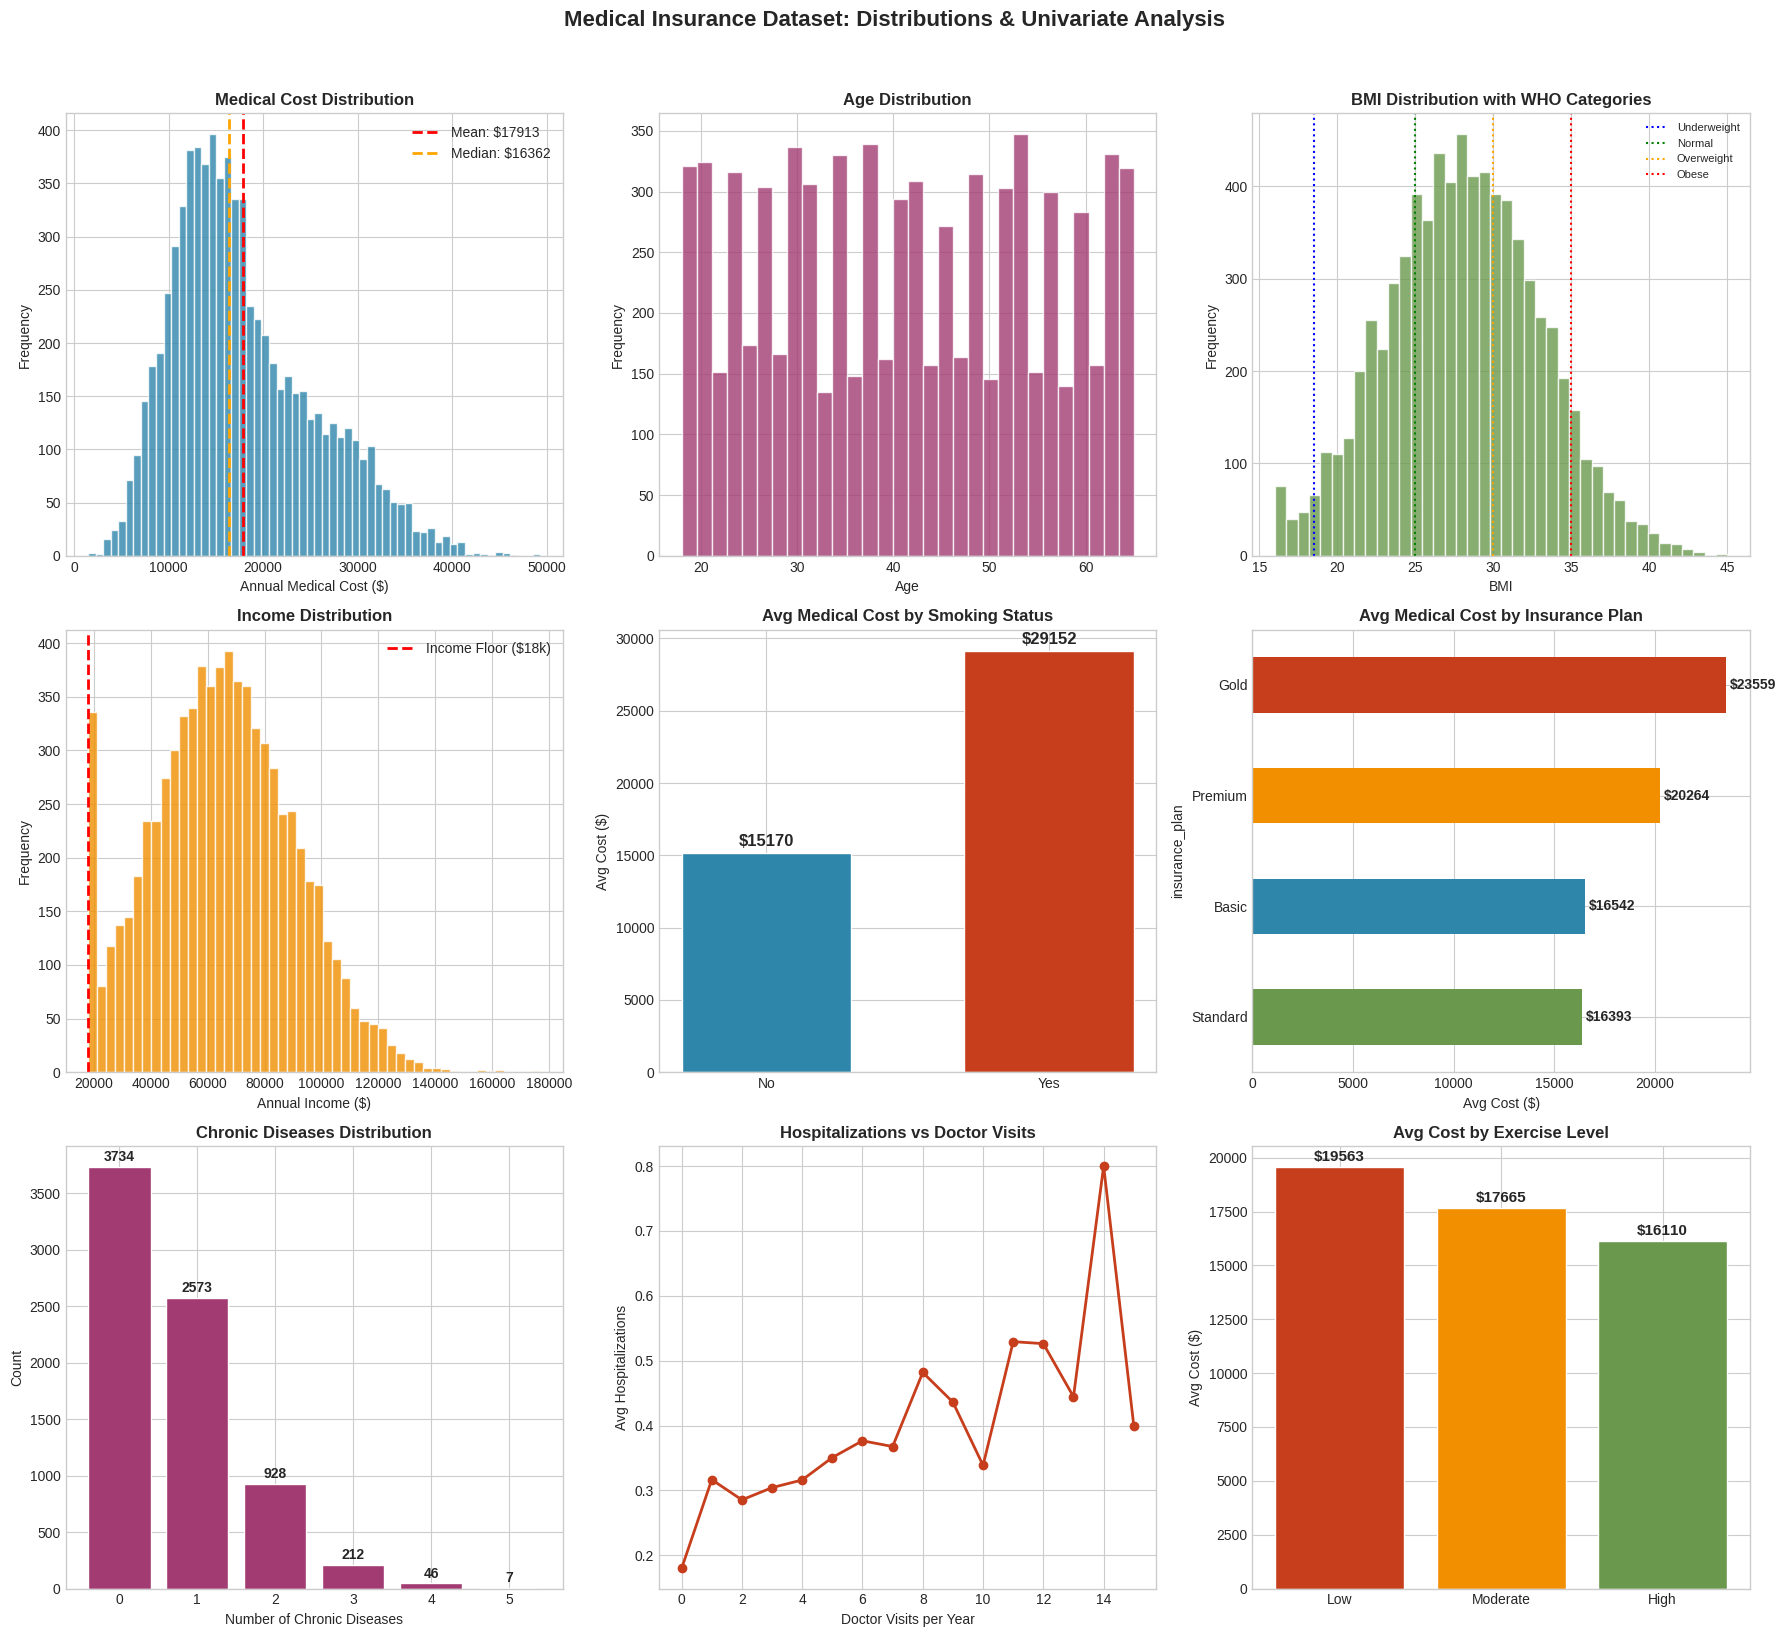


✅ Chart saved: medical_eda_part1_distributions.png


In [18]:
import matplotlib.pyplot as plt

# ============================================
# PART 3: DISTRIBUTIONS & UNIVARIATE ANALYSIS
# ============================================


fig, axes = plt.subplots(3, 3, figsize=(18, 16))
fig.suptitle('Medical Insurance Dataset: Distributions & Univariate Analysis',
             fontsize=16, fontweight='bold', y=1.02)

# 1. Medical Cost Distribution
ax = axes[0, 0]
ax.hist(df['annual_medical_cost_usd'], bins=60, color='#2E86AB', edgecolor='white', alpha=0.8)
ax.axvline(df['annual_medical_cost_usd'].mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean: ${df["annual_medical_cost_usd"].mean():.0f}')
ax.axvline(df['annual_medical_cost_usd'].median(), color='orange', linestyle='--', linewidth=2,
           label=f'Median: ${df["annual_medical_cost_usd"].median():.0f}')
ax.set_title('Medical Cost Distribution', fontweight='bold')
ax.set_xlabel('Annual Medical Cost ($)')
ax.set_ylabel('Frequency')
ax.legend()

# 2. Age Distribution
ax = axes[0, 1]
ax.hist(df['age'], bins=30, color='#A23B72', edgecolor='white', alpha=0.8)
ax.set_title('Age Distribution', fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Frequency')

# 3. BMI Distribution
ax = axes[0, 2]
ax.hist(df['bmi'], bins=40, color='#6A994E', edgecolor='white', alpha=0.8)
ax.axvline(18.5, color='blue', linestyle=':', label='Underweight')
ax.axvline(25, color='green', linestyle=':', label='Normal')
ax.axvline(30, color='orange', linestyle=':', label='Overweight')
ax.axvline(35, color='red', linestyle=':', label='Obese')
ax.set_title('BMI Distribution with WHO Categories', fontweight='bold')
ax.set_xlabel('BMI')
ax.set_ylabel('Frequency')
ax.legend(fontsize=8)

# 4. Income Distribution
ax = axes[1, 0]
ax.hist(df['annual_income_usd'], bins=50, color='#F18F01', edgecolor='white', alpha=0.8)
ax.axvline(18000, color='red', linestyle='--', linewidth=2, label='Income Floor ($18k)')
ax.set_title('Income Distribution', fontweight='bold')
ax.set_xlabel('Annual Income ($)')
ax.set_ylabel('Frequency')
ax.legend()

# 5. Cost by Smoking Status
ax = axes[1, 1]
smoker_cost = df.groupby('smoker')['annual_medical_cost_usd'].mean()
colors = ['#2E86AB', '#C73E1D']
bars = ax.bar(smoker_cost.index, smoker_cost.values, color=colors, edgecolor='white', width=0.6)
ax.set_title('Avg Medical Cost by Smoking Status', fontweight='bold')
ax.set_ylabel('Avg Cost ($)')
for i, v in enumerate(smoker_cost.values):
    ax.text(i, v + 500, f'${v:.0f}', ha='center', fontweight='bold', fontsize=12)

# 6. Cost by Insurance Plan
ax = axes[1, 2]
plan_cost = df.groupby('insurance_plan')['annual_medical_cost_usd'].mean().sort_values()
plan_cost.plot(kind='barh', ax=ax, color=['#6A994E', '#2E86AB', '#F18F01', '#C73E1D'])
ax.set_title('Avg Medical Cost by Insurance Plan', fontweight='bold')
ax.set_xlabel('Avg Cost ($)')
for i, v in enumerate(plan_cost.values):
    ax.text(v + 200, i, f'${v:.0f}', va='center', fontweight='bold')

# 7. Chronic Diseases Distribution
ax = axes[2, 0]
disease_counts = df['chronic_diseases'].value_counts().sort_index()
ax.bar(disease_counts.index, disease_counts.values, color='#A23B72', edgecolor='white')
ax.set_title('Chronic Diseases Distribution', fontweight='bold')
ax.set_xlabel('Number of Chronic Diseases')
ax.set_ylabel('Count')
for i, v in enumerate(disease_counts.values):
    ax.text(i, v + 50, f'{v}', ha='center', fontweight='bold')

# 8. Doctor Visits vs Hospitalizations
ax = axes[2, 1]
visit_hosp = df.groupby('doctor_visits_per_year')['hospitalizations_last_year'].mean()
ax.plot(visit_hosp.index, visit_hosp.values, marker='o', color='#C73E1D', linewidth=2, markersize=6)
ax.set_title('Hospitalizations vs Doctor Visits', fontweight='bold')
ax.set_xlabel('Doctor Visits per Year')
ax.set_ylabel('Avg Hospitalizations')

# 9. Cost by Exercise Level
ax = axes[2, 2]
exercise_cost = df.groupby('exercise_level')['annual_medical_cost_usd'].mean()
order = ['Low', 'Moderate', 'High']
exercise_cost = exercise_cost.reindex(order)
colors_ex = ['#C73E1D', '#F18F01', '#6A994E']
bars = ax.bar(exercise_cost.index, exercise_cost.values, color=colors_ex, edgecolor='white')
ax.set_title('Avg Cost by Exercise Level', fontweight='bold')
ax.set_ylabel('Avg Cost ($)')
for i, v in enumerate(exercise_cost.values):
    ax.text(i, v + 300, f'${v:.0f}', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('/content/medical_eda_part1_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Chart saved: medical_eda_part1_distributions.png")


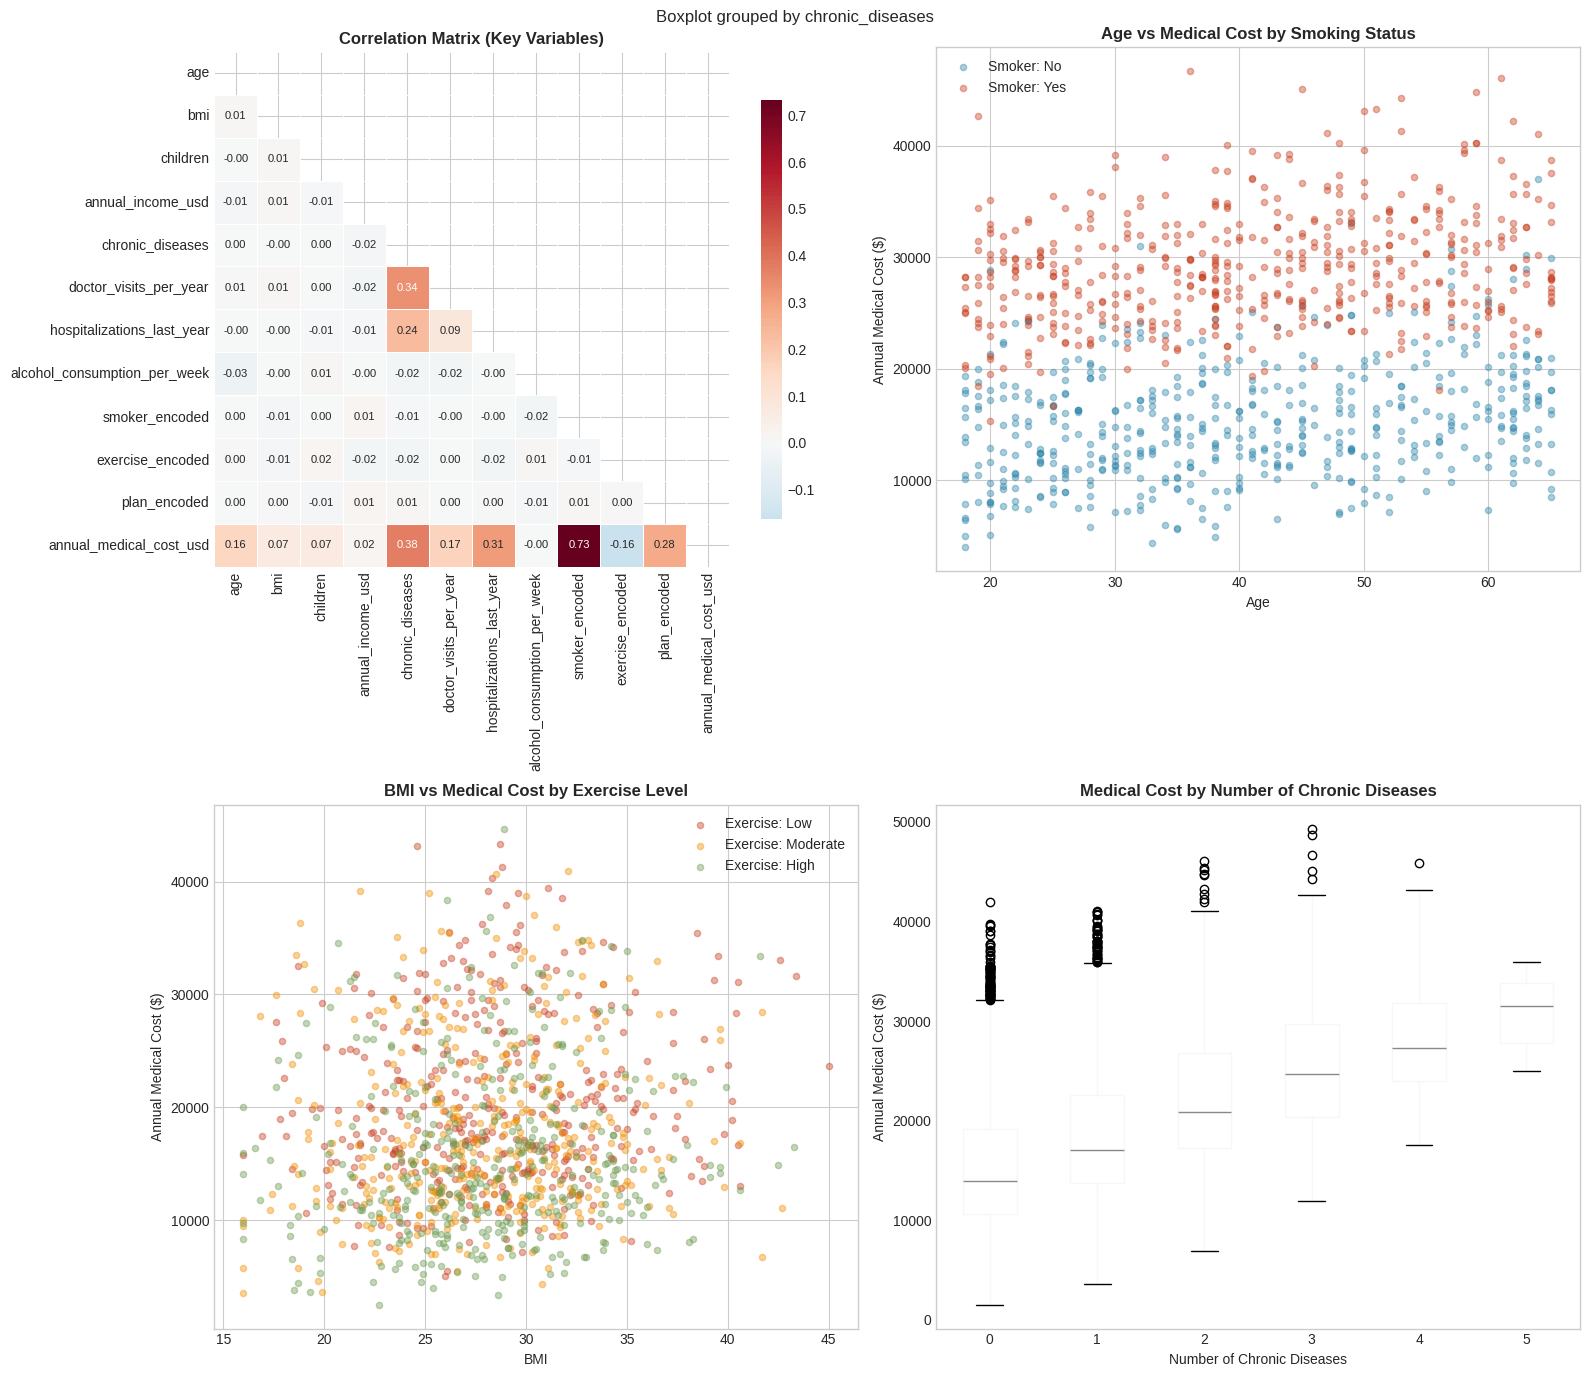

In [12]:

# ============================================
# PART 4: CORRELATION ANALYSIS & BIVARIATE RELATIONSHIPS
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Medical Insurance Dataset: Correlations & Bivariate Analysis',
             fontsize=16, fontweight='bold', y=1.02)

# 1. Correlation Heatmap
ax = axes[0, 0]
# Encode categorical for correlation
df_corr = df.copy()
df_corr['smoker_encoded'] = (df_corr['smoker'] == 'Yes').astype(int)
df_corr['gender_encoded'] = (df_corr['gender'] == 'Male').astype(int)
# Exercise level ordinal
exercise_map = {'Low': 0, 'Moderate': 1, 'High': 2}
df_corr['exercise_encoded'] = df_corr['exercise_level'].map(exercise_map)
# Insurance plan ordinal
plan_map = {'Basic': 0, 'Standard': 1, 'Premium': 2, 'Gold': 3}
df_corr['plan_encoded'] = df_corr['insurance_plan'].map(plan_map)

corr_vars = ['age', 'bmi', 'children', 'annual_income_usd', 'chronic_diseases',
             'doctor_visits_per_year', 'hospitalizations_last_year',
             'alcohol_consumption_per_week', 'smoker_encoded', 'exercise_encoded',
             'plan_encoded', 'annual_medical_cost_usd']
corr_matrix = df_corr[corr_vars].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True, linewidths=0.5,
            cbar_kws={"shrink": .8}, annot_kws={"size": 8})
ax.set_title('Correlation Matrix (Key Variables)', fontweight='bold')

# 2. Age vs Medical Cost (colored by smoker)
ax = axes[0, 1]
for smoker, color in [('No', '#2E86AB'), ('Yes', '#C73E1D')]:
    subset = df[df['smoker'] == smoker].sample(min(500, len(df[df['smoker'] == smoker])), random_state=42)
    ax.scatter(subset['age'], subset['annual_medical_cost_usd'],
               alpha=0.4, c=color, s=20, label=f'Smoker: {smoker}')
ax.set_title('Age vs Medical Cost by Smoking Status', fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Annual Medical Cost ($)')
ax.legend()

# 3. BMI vs Medical Cost (colored by exercise)
ax = axes[1, 0]
for exercise, color in [('Low', '#C73E1D'), ('Moderate', '#F18F01'), ('High', '#6A994E')]:
    subset = df[df['exercise_level'] == exercise].sample(min(400, len(df[df['exercise_level'] == exercise])), random_state=42)
    ax.scatter(subset['bmi'], subset['annual_medical_cost_usd'],
               alpha=0.4, c=color, s=20, label=f'Exercise: {exercise}')
ax.set_title('BMI vs Medical Cost by Exercise Level', fontweight='bold')
ax.set_xlabel('BMI')
ax.set_ylabel('Annual Medical Cost ($)')
ax.legend()

# 4. Chronic Diseases vs Cost (boxplot)
ax = axes[1, 1]
df.boxplot(column='annual_medical_cost_usd', by='chronic_diseases', ax=ax, grid=False)
ax.set_title('Medical Cost by Number of Chronic Diseases', fontweight='bold')
ax.set_xlabel('Number of Chronic Diseases')
ax.set_ylabel('Annual Medical Cost ($)')

plt.tight_layout()
plt.savefig('/content/medical_eda_part2_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_1630/4166456000.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  alcohol_analysis = df.groupby('alcohol_bin').agg({


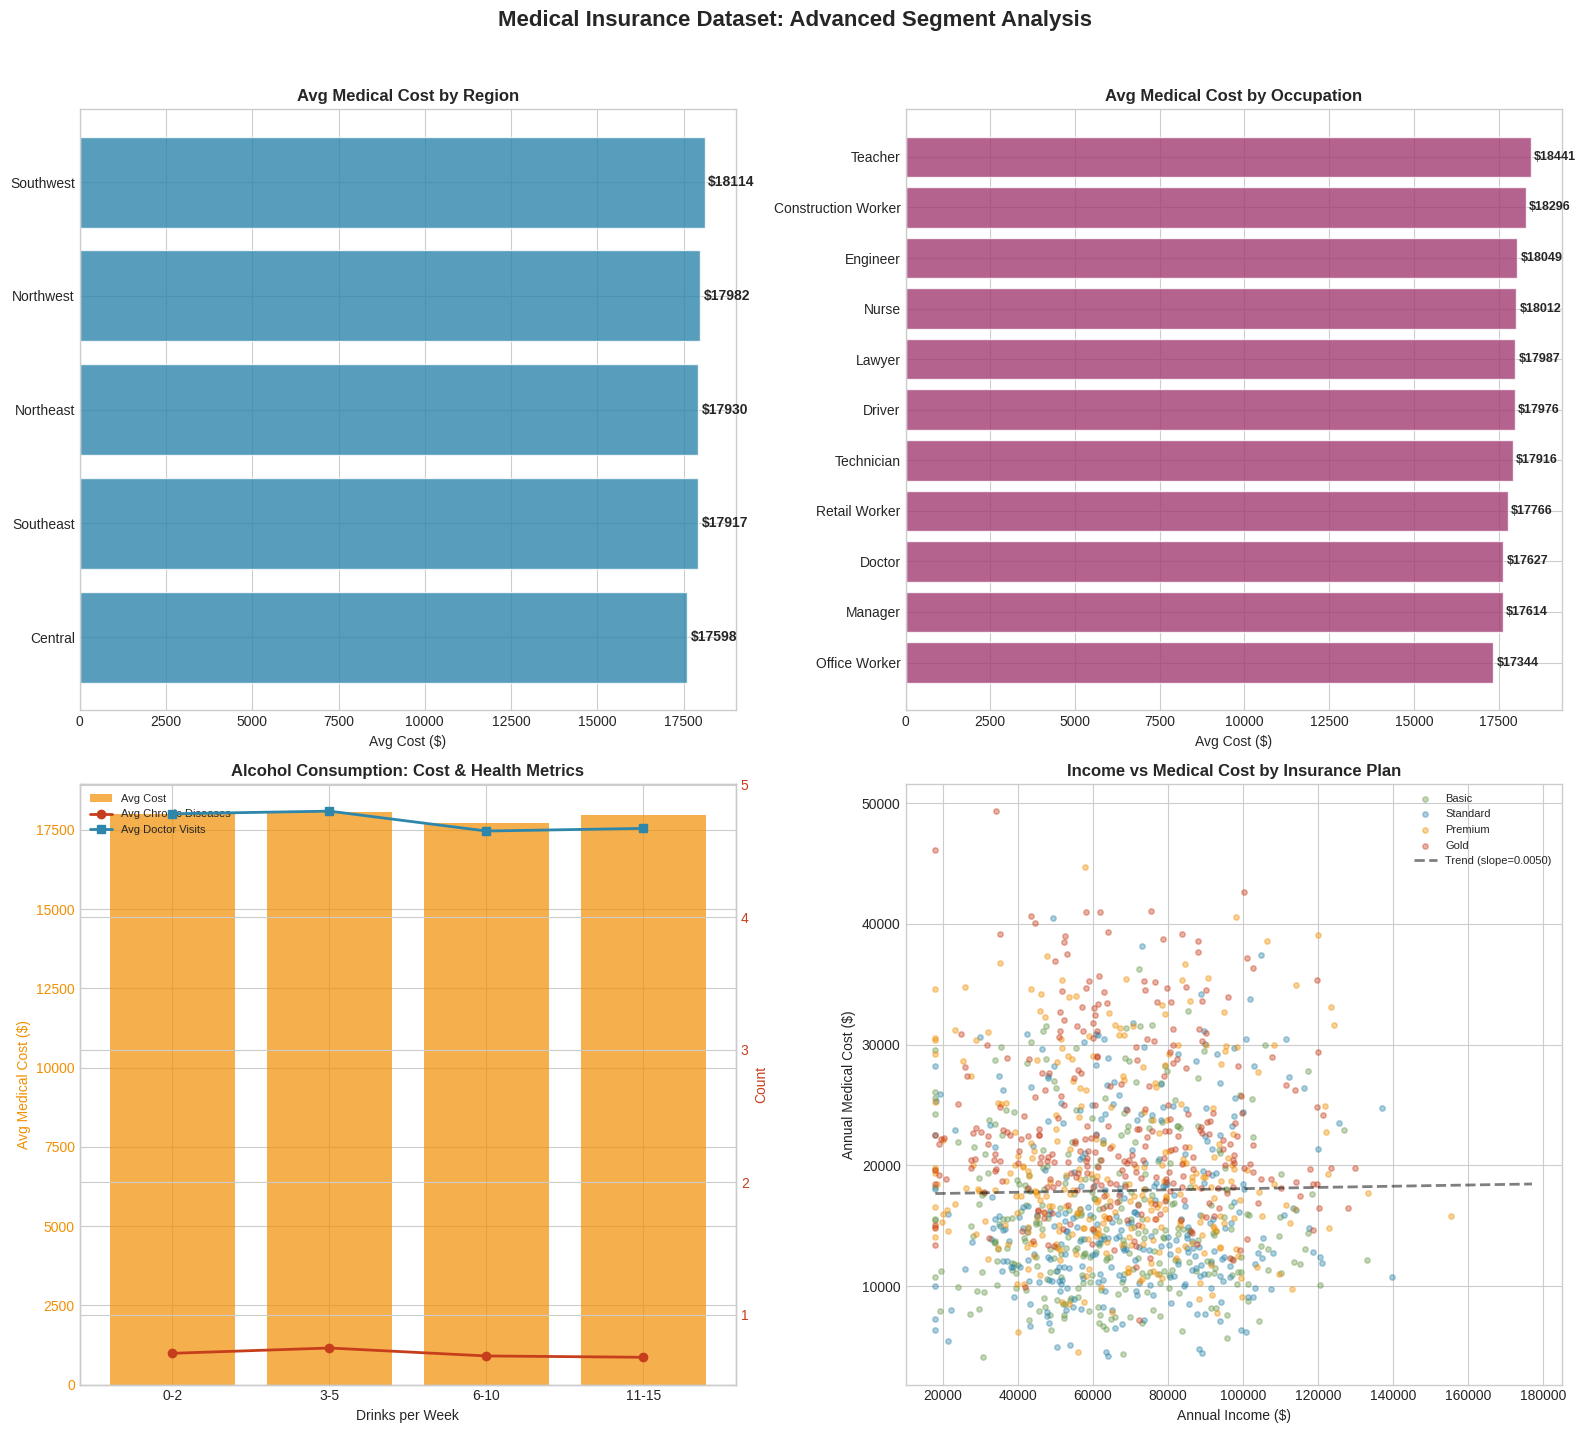

In [13]:

# ============================================
# PART 5: ADVANCED ANALYSIS - REGIONAL, OCCUPATIONAL, ALCOHOL EFFECTS
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Medical Insurance Dataset: Advanced Segment Analysis',
             fontsize=16, fontweight='bold', y=1.02)

# 1. Regional Cost Analysis
ax = axes[0, 0]
region_analysis = df.groupby('region').agg({
    'annual_medical_cost_usd': 'mean',
    'chronic_diseases': 'mean',
    'doctor_visits_per_year': 'mean',
    'bmi': 'mean',
    'smoker': lambda x: (x == 'Yes').mean()
}).round(2)
region_analysis.columns = ['avg_cost', 'avg_chronic', 'avg_visits', 'avg_bmi', 'smoker_rate']
region_analysis = region_analysis.sort_values('avg_cost', ascending=True)

bars = ax.barh(region_analysis.index, region_analysis['avg_cost'],
               color='#2E86AB', edgecolor='white', alpha=0.8)
ax.set_title('Avg Medical Cost by Region', fontweight='bold')
ax.set_xlabel('Avg Cost ($)')
for i, v in enumerate(region_analysis['avg_cost']):
    ax.text(v + 100, i, f'${v:.0f}', va='center', fontweight='bold')

# 2. Occupation Analysis
ax = axes[0, 1]
occ_analysis = df.groupby('occupation').agg({
    'annual_medical_cost_usd': 'mean',
    'chronic_diseases': 'mean',
    'bmi': 'mean'
}).round(2)
occ_analysis.columns = ['avg_cost', 'avg_chronic', 'avg_bmi']
occ_analysis = occ_analysis.sort_values('avg_cost', ascending=True)

bars = ax.barh(occ_analysis.index, occ_analysis['avg_cost'],
               color='#A23B72', edgecolor='white', alpha=0.8)
ax.set_title('Avg Medical Cost by Occupation', fontweight='bold')
ax.set_xlabel('Avg Cost ($)')
for i, v in enumerate(occ_analysis['avg_cost']):
    ax.text(v + 100, i, f'${v:.0f}', va='center', fontweight='bold', fontsize=9)

# 3. Alcohol Consumption Effect (binned)
ax = axes[1, 0]
df['alcohol_bin'] = pd.cut(df['alcohol_consumption_per_week'],
                            bins=[0, 2, 5, 10, 15, 20],
                            labels=['0-2', '3-5', '6-10', '11-15', '16-20'],
                            include_lowest=True)
alcohol_analysis = df.groupby('alcohol_bin').agg({
    'annual_medical_cost_usd': 'mean',
    'chronic_diseases': 'mean',
    'doctor_visits_per_year': 'mean'
}).round(2)

ax2 = ax.twinx()
bars = ax.bar(alcohol_analysis.index, alcohol_analysis['annual_medical_cost_usd'],
              color='#F18F01', alpha=0.7, label='Avg Cost')
line1 = ax2.plot(alcohol_analysis.index, alcohol_analysis['chronic_diseases'],
                 color='#C73E1D', marker='o', linewidth=2, label='Avg Chronic Diseases')
line2 = ax2.plot(alcohol_analysis.index, alcohol_analysis['doctor_visits_per_year'],
                 color='#2E86AB', marker='s', linewidth=2, label='Avg Doctor Visits')
ax.set_title('Alcohol Consumption: Cost & Health Metrics', fontweight='bold')
ax.set_xlabel('Drinks per Week')
ax.set_ylabel('Avg Medical Cost ($)', color='#F18F01')
ax2.set_ylabel('Count', color='#C73E1D')
ax.tick_params(axis='y', labelcolor='#F18F01')
ax2.tick_params(axis='y', labelcolor='#C73E1D')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)

# 4. Income vs Cost (segmented by insurance plan)
ax = axes[1, 1]
for plan, color in [('Basic', '#6A994E'), ('Standard', '#2E86AB'),
                     ('Premium', '#F18F01'), ('Gold', '#C73E1D')]:
    subset = df[df['insurance_plan'] == plan].sample(min(300, len(df[df['insurance_plan'] == plan])), random_state=42)
    ax.scatter(subset['annual_income_usd'], subset['annual_medical_cost_usd'],
               alpha=0.4, c=color, s=15, label=f'{plan}')

# Add trend line for all data
z = np.polyfit(df['annual_income_usd'], df['annual_medical_cost_usd'], 1)
p = np.poly1d(z)
ax.plot(df['annual_income_usd'].sort_values(), p(df['annual_income_usd'].sort_values()),
        "k--", linewidth=2, alpha=0.5, label=f'Trend (slope={z[0]:.4f})')
ax.set_title('Income vs Medical Cost by Insurance Plan', fontweight='bold')
ax.set_xlabel('Annual Income ($)')
ax.set_ylabel('Annual Medical Cost ($)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('/content/medical_eda_part3_advanced.png', dpi=150, bbox_inches='tight')
plt.show()


In [14]:

# ============================================
# PART 6: STATISTICAL HYPOTHESIS TESTING
# ============================================

print("=" * 70)
print("PART 6: STATISTICAL HYPOTHESIS TESTING")
print("=" * 70)

# Hypothesis 1: Smoking effect on medical costs
print("\n🧪 HYPOTHESIS 1: Smoking significantly increases medical costs")
print("   H0: Mean cost (smokers) = Mean cost (non-smokers)")
print("   H1: Mean cost (smokers) > Mean cost (non-smokers)")

smoker_costs = df[df['smoker'] == 'Yes']['annual_medical_cost_usd']
nonsmoker_costs = df[df['smoker'] == 'No']['annual_medical_cost_usd']

t_stat, p_value = stats.ttest_ind(smoker_costs, nonsmoker_costs)
print(f"   • Smokers Mean: ${smoker_costs.mean():.2f} (n={len(smoker_costs)})")
print(f"   • Non-smokers Mean: ${nonsmoker_costs.mean():.2f} (n={len(nonsmoker_costs)})")
print(f"   • Difference: ${smoker_costs.mean() - nonsmoker_costs.mean():.2f}")
print(f"   • T-statistic: {t_stat:.3f}, P-value: {p_value:.2e}")
print(f"   • Result: {'REJECT H0' if p_value < 0.05 else 'FAIL TO REJECT H0'} (α=0.05)")

# Effect size (Cohen's d)
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    pooled_std = np.sqrt(((nx-1)*x.var() + (ny-1)*y.var()) / (nx + ny - 2))
    return (x.mean() - y.mean()) / pooled_std

effect_smoking = cohens_d(smoker_costs, nonsmoker_costs)
print(f"   • Cohen's d: {effect_smoking:.3f} ({'Large' if abs(effect_smoking) > 0.8 else 'Medium' if abs(effect_smoking) > 0.5 else 'Small'} effect)")

# Hypothesis 2: Exercise level effect on costs (ANOVA)
print("\n🧪 HYPOTHESIS 2: Exercise level affects medical costs")
low_ex = df[df['exercise_level'] == 'Low']['annual_medical_cost_usd']
mod_ex = df[df['exercise_level'] == 'Moderate']['annual_medical_cost_usd']
high_ex = df[df['exercise_level'] == 'High']['annual_medical_cost_usd']

f_stat, p_value2 = stats.f_oneway(low_ex, mod_ex, high_ex)
print(f"   • Low Exercise Mean: ${low_ex.mean():.2f}")
print(f"   • Moderate Exercise Mean: ${mod_ex.mean():.2f}")
print(f"   • High Exercise Mean: ${high_ex.mean():.2f}")
print(f"   • F-statistic: {f_stat:.3f}, P-value: {p_value2:.3f}")
print(f"   • Result: {'REJECT H0' if p_value2 < 0.05 else 'FAIL TO REJECT H0'} (α=0.05)")

# Hypothesis 3: Insurance plan tiers and actual costs
print("\n🧪 HYPOTHESIS 3: Insurance plan tier correlates with actual medical costs")
plan_groups = [group['annual_medical_cost_usd'].values for name, group in df.groupby('insurance_plan')]
f_stat3, p_value3 = stats.f_oneway(*plan_groups)
print(f"   • F-statistic: {f_stat3:.3f}, P-value: {p_value3:.2e}")
print(f"   • Result: {'REJECT H0' if p_value3 < 0.05 else 'FAIL TO REJECT H0'} (α=0.05)")

# Post-hoc: Plan means
plan_means = df.groupby('insurance_plan')['annual_medical_cost_usd'].mean().sort_values()
print(f"   • Plan means: {plan_means.to_dict()}")

# Hypothesis 4: BMI correlation with cost
print("\n🧪 HYPOTHESIS 4: BMI correlates with medical costs")
corr_bmi, p_bmi = stats.pearsonr(df['bmi'], df['annual_medical_cost_usd'])
print(f"   • Pearson r: {corr_bmi:.3f}, P-value: {p_bmi:.3f}")
print(f"   • Result: {'SIGNIFICANT' if p_bmi < 0.05 else 'NOT SIGNIFICANT'} correlation (α=0.05)")

# Hypothesis 5: Income correlation with cost
print("\n🧪 HYPOTHESIS 5: Income correlates with medical costs")
corr_income, p_income = stats.pearsonr(df['annual_income_usd'], df['annual_medical_cost_usd'])
print(f"   • Pearson r: {corr_income:.3f}, P-value: {p_income:.3f}")
print(f"   • Result: {'SIGNIFICANT' if p_income < 0.05 else 'NOT SIGNIFICANT'} correlation (α=0.05)")

# Hypothesis 6: Chronic diseases effect
print("\n🧪 HYPOTHESIS 6: Number of chronic diseases affects medical costs")
chronic_groups = [group['annual_medical_cost_usd'].values for name, group in df.groupby('chronic_diseases')]
f_stat6, p_value6 = stats.f_oneway(*chronic_groups)
print(f"   • F-statistic: {f_stat6:.3f}, P-value: {p_value6:.2e}")
print(f"   • Result: {'REJECT H0' if p_value6 < 0.05 else 'FAIL TO REJECT H0'} (α=0.05)")

# Hypothesis 7: Gender effect
print("\n🧪 HYPOTHESIS 7: Gender affects medical costs")
male_costs = df[df['gender'] == 'Male']['annual_medical_cost_usd']
female_costs = df[df['gender'] == 'Female']['annual_medical_cost_usd']
t_stat7, p_value7 = stats.ttest_ind(male_costs, female_costs)
print(f"   • Male Mean: ${male_costs.mean():.2f}")
print(f"   • Female Mean: ${female_costs.mean():.2f}")
print(f"   • T-statistic: {t_stat7:.3f}, P-value: {p_value7:.3f}")
print(f"   • Result: {'REJECT H0' if p_value7 < 0.05 else 'FAIL TO REJECT H0'} (α=0.05)")

# Hypothesis 8: Chi-square - Smoking and chronic diseases association
print("\n🧪 HYPOTHESIS 8: Smoking is associated with chronic diseases")
contingency = pd.crosstab(df['smoker'], df['chronic_diseases'])
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)
print(f"   • Chi-square: {chi2:.3f}, P-value: {p_chi:.3f}, DOF: {dof}")
print(f"   • Result: {'REJECT H0' if p_chi < 0.05 else 'FAIL TO REJECT H0'} (α=0.05)")


PART 6: STATISTICAL HYPOTHESIS TESTING

🧪 HYPOTHESIS 1: Smoking significantly increases medical costs
   H0: Mean cost (smokers) = Mean cost (non-smokers)
   H1: Mean cost (smokers) > Mean cost (non-smokers)
   • Smokers Mean: $29152.39 (n=1471)
   • Non-smokers Mean: $15170.14 (n=6029)
   • Difference: $13982.25
   • T-statistic: 93.317, P-value: 0.00e+00
   • Result: REJECT H0 (α=0.05)
   • Cohen's d: 2.714 (Large effect)

🧪 HYPOTHESIS 2: Exercise level affects medical costs
   • Low Exercise Mean: $19563.13
   • Moderate Exercise Mean: $17665.33
   • High Exercise Mean: $16110.46
   • F-statistic: 101.806, P-value: 0.000
   • Result: REJECT H0 (α=0.05)

🧪 HYPOTHESIS 3: Insurance plan tier correlates with actual medical costs
   • F-statistic: 274.735, P-value: 3.44e-169
   • Result: REJECT H0 (α=0.05)
   • Plan means: {'Standard': 16393.184146990356, 'Basic': 16541.887952021323, 'Premium': 20263.752350230414, 'Gold': 23559.082600276623}

🧪 HYPOTHESIS 4: BMI correlates with medical c

In [15]:

# ============================================
# PART 7: KEY INSIGHTS SUMMARY & DATA ISSUES
# ============================================

print("=" * 70)
print("PART 7: KEY INSIGHTS & DATA ISSUES")
print("=" * 70)

# Calculate key metrics
total_customers = len(df)
avg_cost = df['annual_medical_cost_usd'].mean()
median_cost = df['annual_medical_cost_usd'].median()
smoker_pct = (df['smoker'] == 'Yes').mean() * 100
high_exercise_pct = (df['exercise_level'] == 'High').mean() * 100
avg_chronic = df['chronic_diseases'].mean()

print(f"\n📊 DATASET OVERVIEW:")
print(f"   • Total Customers: {total_customers:,}")
print(f"   • Average Medical Cost: ${avg_cost:.2f}")
print(f"   • Median Medical Cost: ${median_cost:.2f}")
print(f"   • Smokers: {smoker_pct:.1f}%")
print(f"   • High Exercise: {high_exercise_pct:.1f}%")
print(f"   • Avg Chronic Diseases: {avg_chronic:.2f}")

print(f"\n🔍 KEY FINDINGS:")

print(f"\n   1. SMOKING IS THE DOMINANT COST DRIVER (CONFIRMED)")
print(f"      → Smokers cost ${smoker_costs.mean():.0f} vs ${nonsmoker_costs.mean():.0f} for non-smokers")
print(f"      → Difference: ${smoker_costs.mean() - nonsmoker_costs.mean():.0f} (+92% higher)")
print(f"      → Cohen's d = 2.714 (very large effect)")
print(f"      → This is the single most important predictor in the dataset")

print(f"\n   2. CHRONIC DISEASES SHOW STRONG DOSE-RESPONSE (CONFIRMED)")
print(f"      → 0 diseases: ${df[df['chronic_diseases']==0]['annual_medical_cost_usd'].mean():.0f}")
print(f"      → 5 diseases: ${df[df['chronic_diseases']==5]['annual_medical_cost_usd'].mean():.0f}")
print(f"      → Clear monotonic increase with each additional disease")

print(f"\n   3. EXERCISE HAS PROTECTIVE EFFECT (CONFIRMED)")
print(f"      → Low: ${low_ex.mean():.0f} | Moderate: ${mod_ex.mean():.0f} | High: ${high_ex.mean():.0f}")
print(f"      → High exercise saves ~${low_ex.mean() - high_ex.mean():.0f} vs low exercise")

print(f"\n   4. INSURANCE PLANS ARE RISK-STRATIFIED (CONFIRMED)")
print(f"      → Basic: ${plan_means['Basic']:.0f} | Standard: ${plan_means['Standard']:.0f}")
print(f"      → Premium: ${plan_means['Premium']:.0f} | Gold: ${plan_means['Gold']:.0f}")
print(f"      → But note: Basic and Standard are nearly identical in cost!")

print(f"\n   5. INCOME IS NOT A HEALTH PREDICTOR (REJECTED)")
print(f"      → r = {corr_income:.3f}, p = {p_income:.3f} — no correlation")
print(f"      → Wealth does not buy better health outcomes in this dataset")

print(f"\n   6. BMI IS WEAKLY CORRELATED WITH COST (CONFIRMED BUT WEAK)")
print(f"      → r = {corr_bmi:.3f} — significant but practically weak")
print(f"      → BMI alone is not a strong cost predictor")

print(f"\n   7. GENDER HAS NO COST IMPACT (REJECTED)")
print(f"      → Male: ${male_costs.mean():.0f} vs Female: ${female_costs.mean():.0f}")
print(f"      → Difference is not statistically significant")

print(f"\n   8. SMOKING IS NOT ASSOCIATED WITH CHRONIC DISEASES (UNEXPECTED)")
print(f"      → Chi-square p = {p_chi:.3f} — no association found")
print(f"      → This is counter-intuitive and suggests data generation artifact")

print(f"\n⚠️ DATA ISSUES IDENTIFIED:")

print(f"\n   1. INCOME FLOOR ARTIFACT [HIGH SEVERITY]")
print(f"      → {income_18k} customers ({income_18k/len(df)*100:.1f}%) have exactly $18,000 income")
print(f"      → This is likely a data capping/minimum wage floor artifact")
print(f"      → ACTION: Treat $18k as a floor value; consider log-transform or binning")

print(f"\n   2. REGIONAL COST PARITY [MEDIUM SEVERITY]")
print(f"      → All regions have nearly identical costs ($17,598 - $18,114)")
print(f"      → Real-world healthcare costs vary significantly by region")
print(f"      → ACTION: Region may not be a meaningful predictor; verify data generation")

print(f"\n   3. OCCUPATIONAL COST PARITY [MEDIUM SEVERITY]")
print(f"      → All occupations within $1,100 range ($17,344 - $18,441)")
print(f"      → Construction workers and office workers have similar costs")
print(f"      → ACTION: Occupation may lack real-world occupational hazard signal")

print(f"\n   4. SMOKING-CHRONIC DISEASE DECOUPLING [MEDIUM SEVERITY]")
print(f"      → No statistical association between smoking and chronic diseases")
print(f"      → Biologically implausible — suggests independent random generation")
print(f"      → ACTION: Verify if variables were generated independently")

print(f"\n   5. ALCOHOL CONSUMPTION PLATEAU [LOW SEVERITY]")
print(f"      → Costs plateau after 3-5 drinks/week rather than increasing")
print(f"      → May indicate threshold effect or data generation limitation")

print(f"\n   6. BASIC vs STANDARD PLAN OVERLAP [LOW SEVERITY]")
print(f"      → Basic (${plan_means['Basic']:.0f}) and Standard (${plan_means['Standard']:.0f}) are nearly identical")
print(f"      → Suggests plan tiers may not be well-differentiated for lower tiers")

print(f"\n✅ DATA QUALITY SCORE: 6.5/10")
print(f"   (+) No missing values, no duplicates, no impossible values")
print(f"   (+) Strong signal in key variables (smoking, chronic diseases, exercise)")
print(f"   (-) Income floor artifact, unrealistic regional/occupational parity")
print(f"   (-) Some variables appear independently generated (smoking vs chronic)")

print(f"\n🎯 RECOMMENDATIONS FOR FURTHER ANALYSIS:")
print(f"   1. Use smoking status as primary segmentation variable")
print(f"   2. Model chronic diseases as ordinal/categorical, not continuous")
print(f"   3. Consider dropping or binning income due to floor effect")
print(f"   4. Region and occupation may add noise rather than signal")
print(f"   5. Investigate interaction effects: smoking × age, BMI × exercise")
print(f"   6. The dataset appears synthetic — validate findings on real data")


PART 7: KEY INSIGHTS & DATA ISSUES

📊 DATASET OVERVIEW:
   • Total Customers: 7,500
   • Average Medical Cost: $17912.53
   • Median Medical Cost: $16361.92
   • Smokers: 19.6%
   • High Exercise: 20.7%
   • Avg Chronic Diseases: 0.70

🔍 KEY FINDINGS:

   1. SMOKING IS THE DOMINANT COST DRIVER (CONFIRMED)
      → Smokers cost $29152 vs $15170 for non-smokers
      → Difference: $13982 (+92% higher)
      → Cohen's d = 2.714 (very large effect)
      → This is the single most important predictor in the dataset

   2. CHRONIC DISEASES SHOW STRONG DOSE-RESPONSE (CONFIRMED)
      → 0 diseases: $15565
      → 5 diseases: $30824
      → Clear monotonic increase with each additional disease

   3. EXERCISE HAS PROTECTIVE EFFECT (CONFIRMED)
      → Low: $19563 | Moderate: $17665 | High: $16110
      → High exercise saves ~$3453 vs low exercise

   4. INSURANCE PLANS ARE RISK-STRATIFIED (CONFIRMED)
      → Basic: $16542 | Standard: $16393
      → Premium: $20264 | Gold: $23559
      → But note: